# Task 3: Exploratory Data Analysis (EDA) Project

**Internship:** Thiranex Data Science Internship  
**Dataset:** Sample Superstore Sales (Tableau / Kaggle)  
**Objective:** Perform an exploratory data analysis to uncover business patterns and sales trends, evaluate correlations and profitability drivers, and summarize actionable insights.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset
data_path = 'data/sample_superstore.csv' if os.path.exists('data/sample_superstore.csv') else 'Task-03-Exploratory-Data-Analysis/data/sample_superstore.csv'
df = pd.read_csv(data_path, encoding='windows-1252')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### 1. Statistical Summary & Data Hygiene
We inspect summary statistics across key numerical features (`Sales`, `Quantity`, `Discount`, `Profit`) and verify data cleanliness.

In [2]:
# Statistical overview
summary = df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)
print("Statistical Summary of Numerical Features:")
print(summary)

# Missing values check
missing = df.isnull().sum()
print("\nMissing Values Count:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

Statistical Summary of Numerical Features:
          Sales  Quantity  Discount   Profit
count   9994.00   9994.00   9994.00  9994.00
mean     229.86      3.79      0.16    28.66
std      623.25      2.23      0.21   234.26
min        0.44      1.00      0.00 -6599.98
25%       17.28      2.00      0.00     1.73
50%       54.49      3.00      0.20     8.67
75%      209.94      5.00      0.20    29.36
max    22638.48     14.00      0.80  8399.98

Missing Values Count:
No missing values found.


### 2. Univariate Analysis: Distributions of Sales & Profit
We examine the distribution of transaction sales and profits to understand skewness and typical order values.

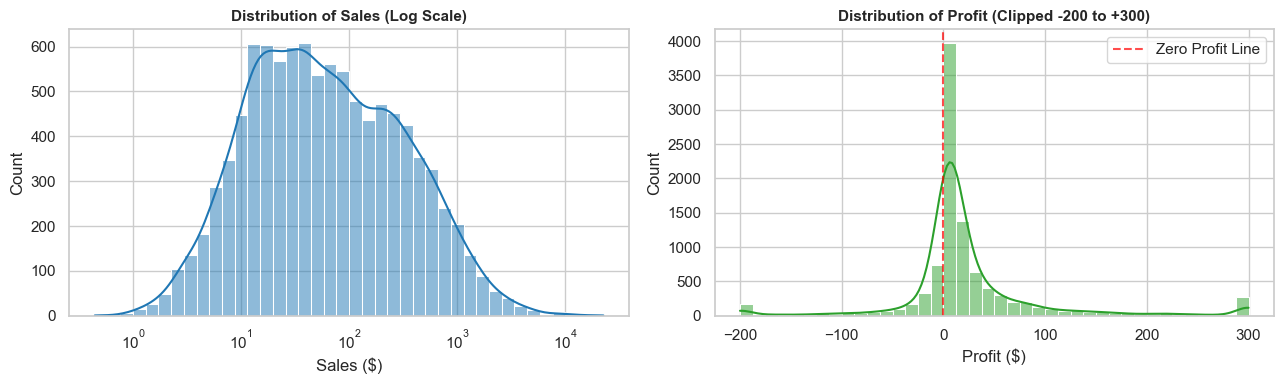

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sales distribution (log scale to handle right skew)
sns.histplot(df['Sales'], bins=40, kde=True, ax=axes[0], color='#1f77b4', log_scale=True)
axes[0].set_title('Distribution of Sales (Log Scale)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Sales ($)')

# Profit distribution (clipped between -200 and 300 for visualization clarity)
sns.histplot(df['Profit'].clip(lower=-200, upper=300), bins=40, kde=True, ax=axes[1], color='#2ca02c')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero Profit Line')
axes[1].set_title('Distribution of Profit (Clipped -200 to +300)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3. Categorical & Regional Breakdown
We compare total Sales and total Profit across Product Categories and Geographic Regions to identify top performers and underperforming segments.

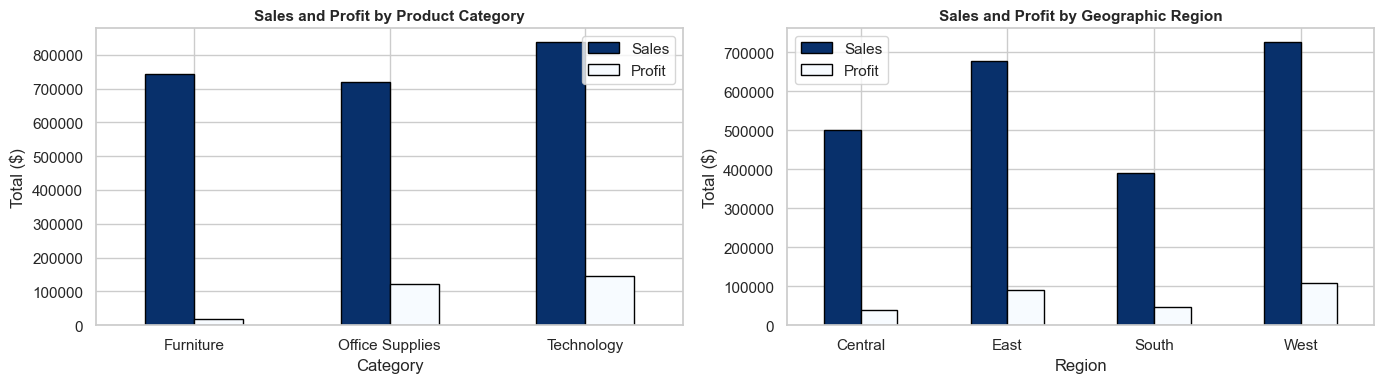

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Performance by Category
cat_summary = df.groupby('Category')[['Sales', 'Profit']].sum()
cat_summary.plot(kind='bar', ax=axes[0], colormap='Blues_r', edgecolor='black')
axes[0].set_title('Sales and Profit by Product Category', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Total ($)')
axes[0].tick_params(axis='x', rotation=0)

# Performance by Region
reg_summary = df.groupby('Region')[['Sales', 'Profit']].sum()
reg_summary.plot(kind='bar', ax=axes[1], colormap='Blues_r', edgecolor='black')
axes[1].set_title('Sales and Profit by Geographic Region', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Total ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 4. Correlation Analysis & Key Influencing Factors
We compute correlation coefficients between numerical metrics to identify the key factors impacting business outcomes.

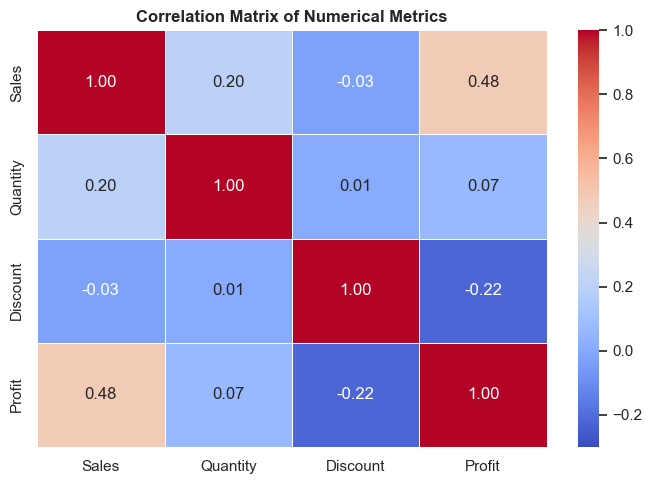

In [5]:
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-0.3, vmax=1.0, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. In-Depth Driver Analysis: Sub-Category Profitability & Discount Impact
We evaluate profitability across all 17 sub-categories and analyze how discount rates affect average profit margins.

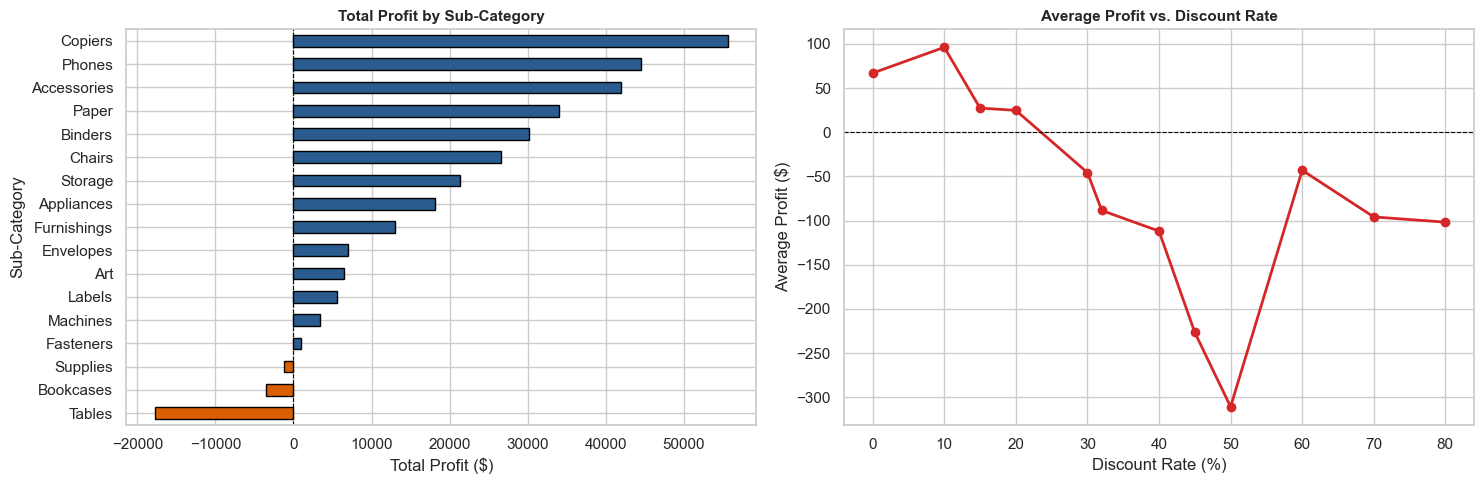

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sub-Category Profitability
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#d95f02' if x < 0 else '#2b5c8f' for x in subcat_profit]
subcat_profit.plot(kind='barh', ax=axes[0], color=colors, edgecolor='black')
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Total Profit by Sub-Category', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')

# Profit vs. Discount Level
discount_profit = df.groupby('Discount')['Profit'].mean()
axes[1].plot(discount_profit.index * 100, discount_profit.values, marker='o', color='#d62728', linewidth=2)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Average Profit vs. Discount Rate', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Discount Rate (%)')
axes[1].set_ylabel('Average Profit ($)')

plt.tight_layout()
plt.show()

### Structured Insights & Summary Report
- **Top Profit Drivers:** Technology is the most lucrative category ($145.5K profit), spearheaded by Copiers ($55.6K) and Phones ($44.5K).
- **Loss-Making Products:** Tables (-$17.7K) and Bookcases (-$3.5K) generate severe net losses due to heavy average discounting.
- **The Discount Dilemma:** A clear negative correlation exists between Discount and Profit (-0.22). Orders with discounts exceeding **20%** consistently yield negative profit margins.
- **Regional Disparities:** The West leads in overall profitability ($108.4K), whereas the Central region generates the lowest profit margin ($39.7K) despite substantial sales volume.
- **Actionable Recommendation:** Cap product discounts at 20% max for furniture sub-categories (Tables, Bookcases) and reallocate marketing budget toward high-margin Technology products.